# 🚨 TASK 3 · Fraud Detection

## 🎯 Objective

Build a machine learning pipeline to detect fraudulent financial transactions from a highly imbalanced dataset.

The project focuses on identifying fraudulent transactions while addressing class imbalance as a core machine learning challenge. Since fraud cases are typically much rarer than legitimate transactions, evaluation will focus on Precision, Recall, F1-Score, and AUC-ROC rather than accuracy alone.

## 🛠️ Tech Stack

- **Python**
- **Pandas**
- **NumPy**
- **Scikit-learn**
  - Logistic Regression
  - Random Forest
- **Imbalanced-learn**
  - SMOTE
- **Matplotlib**
- **Seaborn**
- **Jupyter Notebook**

## 📊 Project Workflow

1. Load and inspect the fraud detection dataset
2. Check missing values and duplicate transactions
3. Analyze the distribution of fraudulent and non-fraudulent transactions
4. Calculate the percentage of fraudulent transactions
5. Perform Exploratory Data Analysis (EDA)
6. Analyze transaction amounts for fraud vs. non-fraud
7. Analyze transaction activity by time of day
8. Explain why accuracy is misleading for imbalanced fraud datasets
9. Apply SMOTE to address class imbalance
10. Perform a stratified train-test split
11. Train Logistic Regression
12. Train Random Forest
13. Evaluate Precision, Recall, F1-Score, and AUC-ROC
14. Plot and compare ROC curves
15. Analyze feature importance / model coefficients
16. Discuss the Precision-Recall trade-off
17. Discuss scalability for high-volume transaction processing
18. Select the most suitable model for fraud detection

## 🎯 Key Evaluation Metrics

- **Precision:** Of the transactions predicted as fraud, how many are actually fraudulent?
- **Recall:** Of all actual fraudulent transactions, how many did the model detect?
- **F1-Score:** Balance between Precision and Recall.
- **AUC-ROC:** Measures how well the model separates fraudulent and legitimate transactions.

## 🏆 Goal

Develop a fraud detection model that can identify fraudulent transactions effectively while minimizing unnecessary false alerts and maintaining the ability to scale to high transaction volumes.

In [ ]:
%pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.


In [5]:
import os

print("Current folder:")
print(os.getcwd())

Current folder:
C:\Users\PAGID


In [6]:
print("\nFiles in current folder:")
print(os.listdir())


Files in current folder:
['.bash_history', '.claude', '.claude.json', '.conda', '.copilot', '.eclipse', '.filmora_tray_version', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.matplotlib', '.p2', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'credit_card_fraud_10k.csv', 'CrossDevice', 'Documents', 'Downloads', 'E-Commence-Performance-Dashboard', 'eclipse', 'edureka-repo', 'Exploratory Data Analysis of Retail Sales Data Using Python', 'Favorites', 'fraud_dataset.csv', 'Fraud_Detection.ipynb', 'github-projects', 'Links', 'Local Settings', 'miniconda3', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{79cee2cf-2a90-11f0-967d-d1aee98516b1}.TM.blf', 'NTUSER.DAT{79cee2cf-2a90-11f0-967d-d1aee98516b1}.TM.blf.cnpf', 'NTUSER.DAT{79cee2cf-2a90-11f0-967d-d1aee98516b1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{79cee2cf-2a90-11f0-967d-d1aee98516b1}.

In [7]:
import pandas as pd

fraud1 = pd.read_csv("credit_card_fraud_10k.csv")
fraud2 = pd.read_csv("fraud_dataset.csv")

print("credit_card_fraud_10k.csv")
print("Shape:", fraud1.shape)
print("Columns:", fraud1.columns.tolist())

print("\n" + "="*60 + "\n")

print("fraud_dataset.csv")
print("Shape:", fraud2.shape)
print("Columns:", fraud2.columns.tolist())

credit_card_fraud_10k.csv
Shape: (10000, 10)
Columns: ['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']


fraud_dataset.csv
Shape: (10000, 10)
Columns: ['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']


In [8]:
print("credit_card_fraud_10k.csv:")
display(fraud1.head())

print("\nfraud_dataset.csv:")
display(fraud2.head())

credit_card_fraud_10k.csv:


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0



fraud_dataset.csv:


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [9]:
df = pd.read_csv("credit_card_fraud_10k.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 10)


In [10]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [12]:
print("Column names:")
print(df.columns.tolist())

Column names:
['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']


In [13]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [14]:
fraud_counts = df["is_fraud"].value_counts()

print("Fraud Distribution:")
print(fraud_counts)

Fraud Distribution:
is_fraud
0    9849
1     151
Name: count, dtype: int64


In [15]:
fraud_percentage = df["is_fraud"].value_counts(normalize=True) * 100

print("Fraud Percentage:")
print(fraud_percentage)

Fraud Percentage:
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


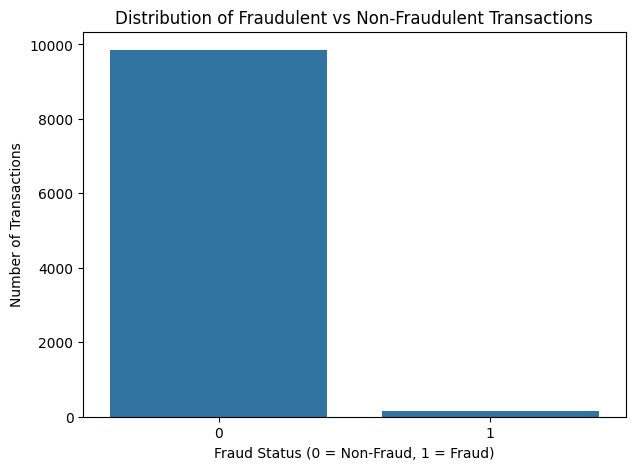

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="is_fraud")

plt.title("Distribution of Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

## Class Imbalance Analysis

The dataset contains 10,000 financial transactions. Among these, 9,849 transactions (98.49%) are legitimate, while only 151 transactions (1.51%) are fraudulent.

This shows a severe class imbalance because fraudulent transactions represent only a small fraction of the total observations.

Class imbalance can cause a machine learning model to favor the majority class. Therefore, a model could achieve high accuracy by predicting most transactions as non-fraud while still failing to detect fraudulent transactions effectively.

For fraud detection, accuracy alone is therefore not a reliable evaluation metric. Precision, Recall, F1-Score, and AUC-ROC are more informative for evaluating the model's ability to identify fraudulent transactions.

In [17]:
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


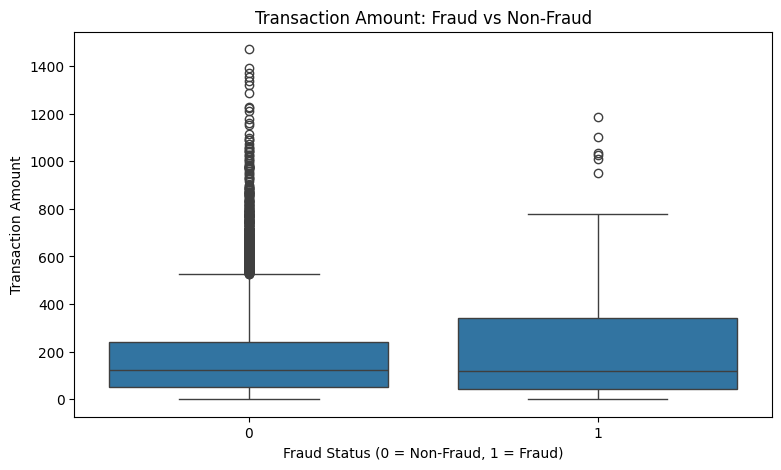

In [19]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount"
)

plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

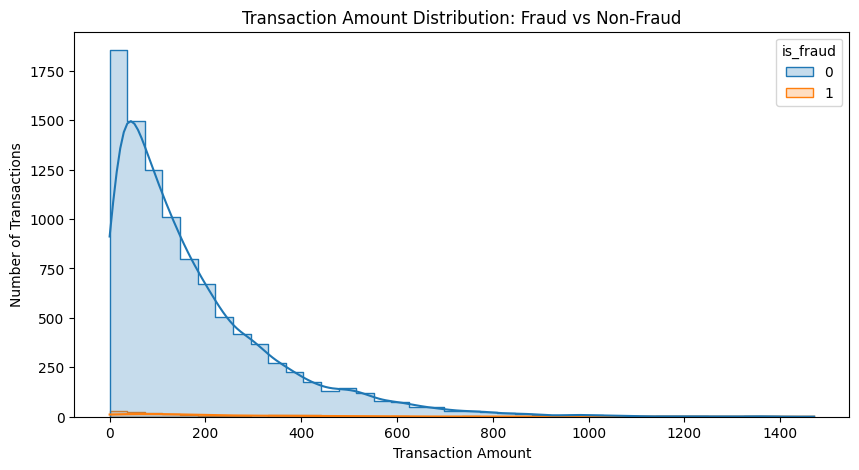

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="amount",
    hue="is_fraud",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

## Transaction Amount Analysis

In [21]:
fraud_by_hour = (
    df.groupby("transaction_hour")["is_fraud"]
    .agg(["sum", "count"])
    .reset_index()
)

fraud_by_hour.columns = [
    "transaction_hour",
    "fraud_count",
    "total_transactions"
]

fraud_by_hour["fraud_rate"] = (
    fraud_by_hour["fraud_count"]
    / fraud_by_hour["total_transactions"]
    * 100
)

fraud_by_hour

,transaction_hour,fraud_count,total_transactions,fraud_rate
0,0,37,417,8.872902
1,1,34,425,8.000000
2,2,23,385,5.974026
3,3,27,425,6.352941
4,4,1,384,0.260417
5,5,2,419,0.477327
6,6,2,413,0.484262
7,7,0,425,0.000000
8,8,3,424,0.707547
9,9,1,426,0.234742


## Time-of-Day Analysis

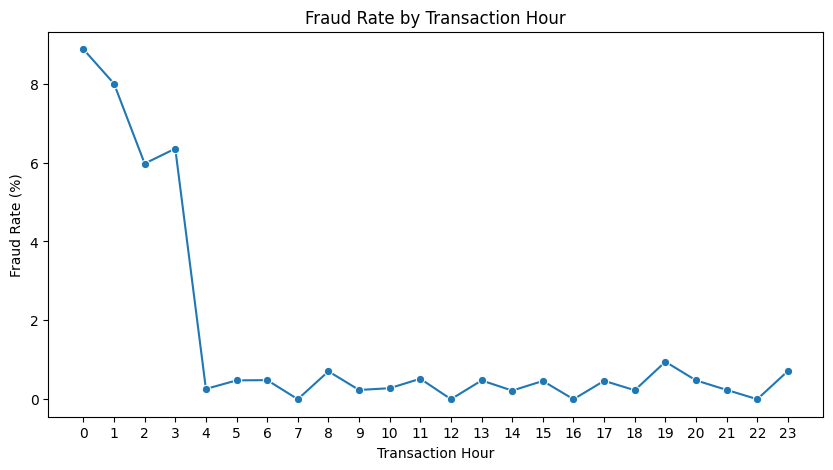

In [22]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=fraud_by_hour,
    x="transaction_hour",
    y="fraud_rate",
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

### 🔍 Observation

* Fraud rate is **highest at Hour 0 (8.87%)**.
* **Hours 1–3** also show high fraud rates (**5.97%–8.00%**).
* After Hour 3, fraud rate drops sharply and stays **below 1%** for most hours.
* **Hours 7, 12, 16, and 22** recorded **0% fraud**.
* Overall, **early-morning transactions (00:00–03:00) are the highest-risk period**.


## Why Accuracy Is a Misleading Metric for Fraud Detection

Fraud detection datasets are usually highly imbalanced, with legitimate transactions greatly outnumbering fraudulent transactions.

In this dataset, 98.49% of transactions are legitimate, while only 1.51% are fraudulent. Because of this imbalance, a model could achieve approximately 98.49% accuracy simply by predicting every transaction as legitimate.

However, such a model would detect zero fraudulent transactions and therefore would be useless for a real-world fraud detection system.

For this reason, accuracy should not be used as the primary evaluation metric. Instead, Precision, Recall, F1-Score, and AUC-ROC provide a more meaningful evaluation of fraud detection performance.

## Precision vs Recall Trade-off

### Recall

Recall measures how many of the actual fraudulent transactions are correctly detected by the model.

A high Recall is important in fraud detection because missing a fraudulent transaction can result in financial loss.

### Precision

Precision measures how many transactions predicted as fraudulent are actually fraudulent.

A high Precision reduces false fraud alerts, which is important because incorrectly blocking legitimate transactions can negatively affect customers.

### Which Metric Matters Most?

For fraud detection, **Recall is often given higher priority** because failing to detect fraud can have a significant financial impact. However, maximizing Recall alone can produce many false positives.

Therefore, a practical fraud detection system should find a balance between Recall and Precision. The **F1-Score** is useful for measuring this balance.

The appropriate balance ultimately depends on the business cost of false negatives versus false positives.

In [23]:
# Remove transaction ID
df_model = df.drop(columns=["transaction_id"])

# Convert categorical variable into numerical columns
df_model = pd.get_dummies(
    df_model,
    columns=["merchant_category"],
    drop_first=True
)

print("Model dataset shape:", df_model.shape)
print(df_model.head())

Model dataset shape: (10000, 12)
   amount  transaction_hour  foreign_transaction  location_mismatch  \
0   84.47                22                    0                  0   
1  541.82                 3                    1                  0   
2  237.01                17                    0                  0   
3  164.33                 4                    0                  1   
4   30.53                15                    0                  0   

   device_trust_score  velocity_last_24h  cardholder_age  is_fraud  \
0                  66                  3              40         0   
1                  87                  1              64         0   
2                  49                  1              61         0   
3                  72                  3              34         0   
4                  79                  0              44         0   

   merchant_category_Electronics  merchant_category_Food  \
0                           True                   False   

In [24]:
X = df_model.drop(columns=["is_fraud"])
y = df_model["is_fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 11)
Target shape: (10000,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 8000
Testing samples: 2000

Training class distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing class distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [27]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [28]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


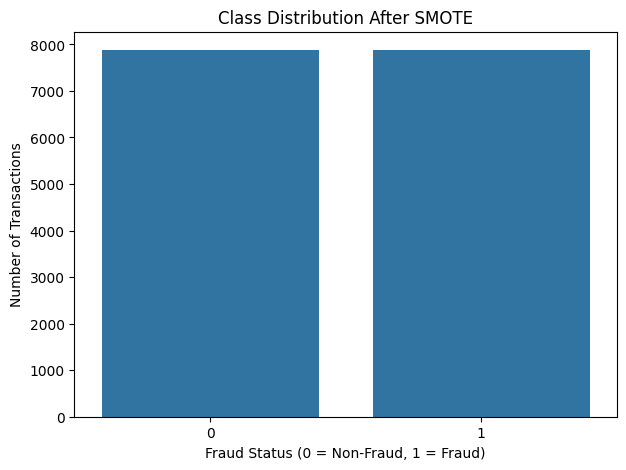

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Fraud Status (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [30]:
scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [31]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [32]:
logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("Logistic Regression Results")
print("---------------------------")
print("Precision :", round(logistic_precision, 4))
print("Recall    :", round(logistic_recall, 4))
print("F1-Score  :", round(logistic_f1, 4))
print("AUC-ROC   :", round(logistic_auc, 4))

Logistic Regression Results
---------------------------
Precision : 0.16
Recall    : 0.9333
F1-Score  : 0.2732
AUC-ROC   : 0.983


In [33]:
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1970
           1       0.16      0.93      0.27        30

    accuracy                           0.93      2000
   macro avg       0.58      0.93      0.62      2000
weighted avg       0.99      0.93      0.95      2000



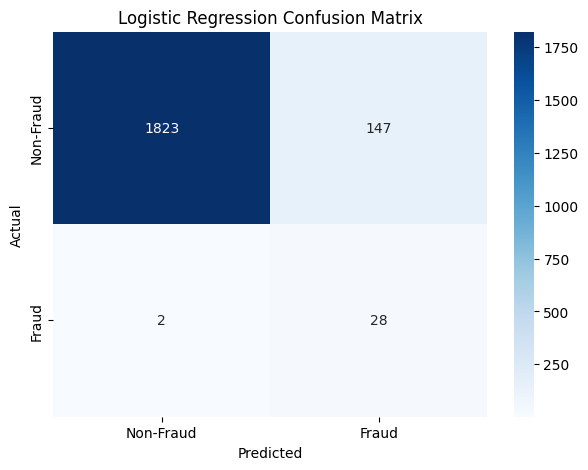

In [34]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

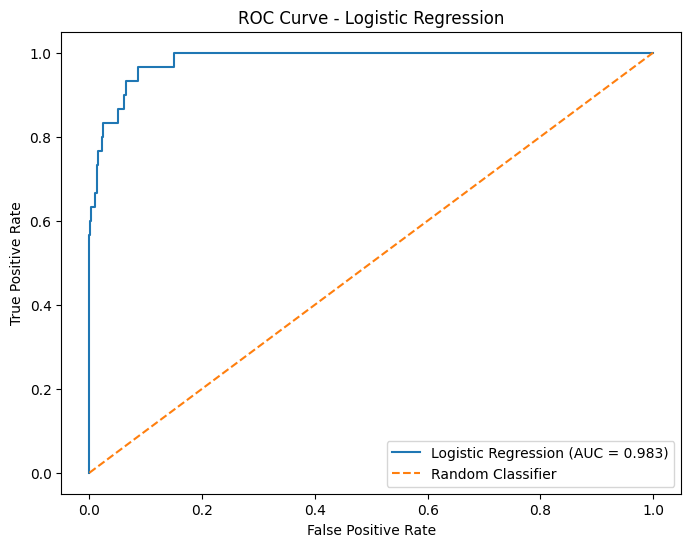

In [35]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### Logistic Regression Results – Interpretation

The Logistic Regression model achieved a Recall of 93.33%, successfully identifying most of the fraudulent transactions in the test set. This high Recall is valuable for fraud detection because missing fraudulent transactions can result in financial losses.

However, the model achieved a Precision of only 16%, indicating that a large number of legitimate transactions were incorrectly classified as fraudulent. Therefore, the model produces many false positives.

The F1-Score was 27.32%, reflecting the trade-off between the high Recall and relatively low Precision. The model achieved an AUC-ROC of 98.30%, indicating strong overall ability to distinguish between fraudulent and legitimate transactions.

Overall, Logistic Regression is effective at detecting fraudulent transactions, but its false-positive rate should be considered before deployment.

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [37]:
rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("Random Forest Results")
print("--------------------")
print("Precision :", round(rf_precision, 4))
print("Recall    :", round(rf_recall, 4))
print("F1-Score  :", round(rf_f1, 4))
print("AUC-ROC   :", round(rf_auc, 4))

Random Forest Results
--------------------
Precision : 0.4583
Recall    : 0.7333
F1-Score  : 0.5641
AUC-ROC   : 0.988


In [38]:
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1970
           1       0.46      0.73      0.56        30

    accuracy                           0.98      2000
   macro avg       0.73      0.86      0.78      2000
weighted avg       0.99      0.98      0.98      2000



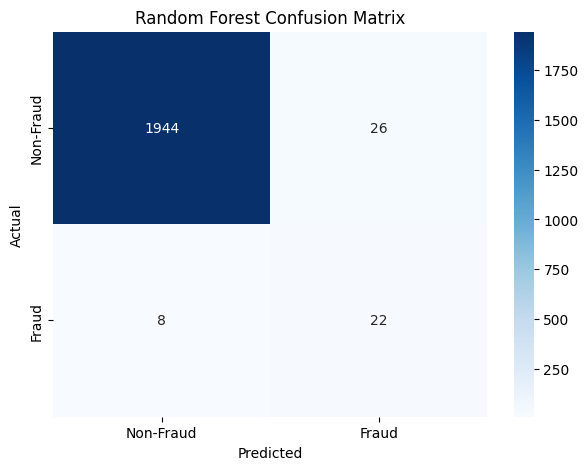

In [39]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

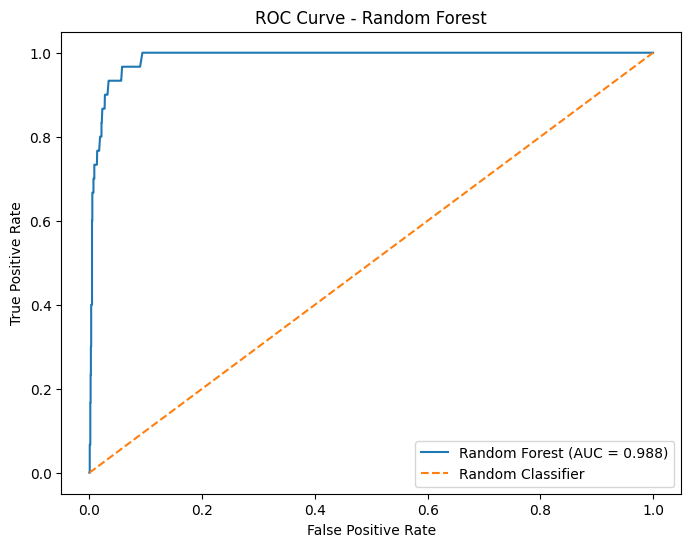

In [40]:
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [41]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,device_trust_score,0.316822
1,transaction_hour,0.245006
0,amount,0.087380
5,velocity_last_24h,0.076868
9,merchant_category_Grocery,0.050719
2,foreign_transaction,0.046875
6,cardholder_age,0.045802
10,merchant_category_Travel,0.041972
8,merchant_category_Food,0.037131
3,location_mismatch,0.031147


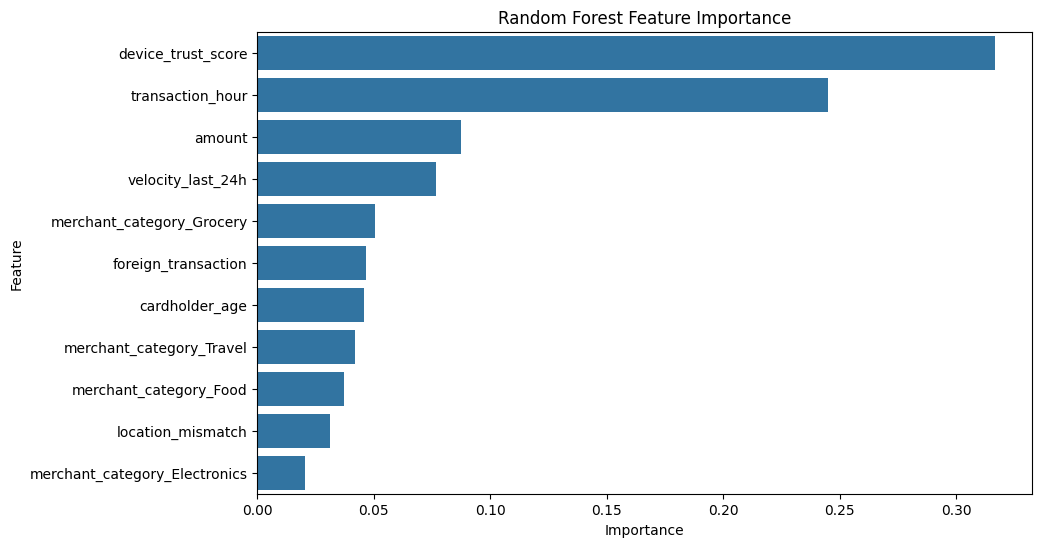

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Feature Importance Analysis

The Random Forest feature importance analysis shows that `device_trust_score` is the most influential feature, with an importance of approximately 31.68%. This suggests that the level of trust associated with the device used for a transaction is an important factor in distinguishing fraudulent transactions.

The second most important feature is `transaction_hour`, with an importance of approximately 24.50%. This indicates that the time at which a transaction occurs contributes significantly to fraud prediction.

`amount` and `velocity_last_24h` are the next important features, with importance values of approximately 8.74% and 7.69%, respectively.

Among the merchant categories, Grocery has the highest importance at approximately 5.07%, followed by Travel and Food.

Overall, the feature importance analysis indicates that device-related characteristics and transaction timing are the strongest predictors in this dataset.

In [43]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1
    ],
    "AUC-ROC": [
        logistic_auc,
        rf_auc
    ]
})

comparison

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.160000,0.933333,0.273171,0.983012
1,Random Forest,0.458333,0.733333,0.564103,0.987953


In [44]:
comparison.round(4)

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.1600,0.9333,0.2732,0.983
1,Random Forest,0.4583,0.7333,0.5641,0.988


## Scalability Discussion

A production fraud detection system may need to process a very large number of transactions in real time. For example, 1 million transactions per hour is approximately 278 transactions per second.

The trained Random Forest model can make predictions efficiently once the model has been trained. However, deploying the system at this scale would require a production-grade architecture rather than running predictions directly from a Jupyter Notebook.

A scalable fraud detection system could use a streaming platform or message queue to receive transactions in real time. A preprocessing service would then transform the incoming transaction data using the same preprocessing steps used during model training.

The trained model could be deployed as a prediction API or model-serving service. Multiple instances of the prediction service could run in parallel behind a load balancer to handle high transaction volumes.

For further scalability, the system could use:
- Batch or real-time feature processing
- Parallel model inference
- Model-serving APIs
- Caching for frequently used features
- Distributed processing
- Cloud-based auto-scaling
- Monitoring for model performance and data drift

Therefore, while the current model is suitable for demonstrating fraud classification on a 10,000-transaction dataset, production deployment for 1 million transactions per hour would require scalable infrastructure, optimized inference, monitoring, and continuous model retraining.

## Conclusion

This project developed a machine learning pipeline for detecting fraudulent financial transactions using a highly imbalanced dataset.

The dataset contained 10,000 transactions, of which only 151 (1.51%) were fraudulent. This severe class imbalance demonstrated why accuracy alone is not an appropriate primary metric for fraud detection.

SMOTE was applied only to the training data to balance the minority fraud class while keeping the test dataset unchanged. Two classification models were trained: Logistic Regression and Random Forest.

Logistic Regression achieved a Recall of 93.33%, meaning it detected most of the actual fraudulent transactions. However, its Precision was only 16%, resulting in a large number of false-positive fraud alerts.

Random Forest achieved a better balance between Precision and Recall. It achieved approximately 46% Precision, 73% Recall, and 56% F1-Score. Therefore, Random Forest provided a more balanced fraud detection performance than Logistic Regression.

The Random Forest feature importance analysis showed that `device_trust_score` and `transaction_hour` were the two most influential features, followed by `amount` and `velocity_last_24h`.

For deployment, Random Forest is the preferred model among the two tested models because it provides a stronger balance between detecting fraud and limiting false fraud alerts. However, the final production model should be selected according to the business cost of missed fraud versus false alerts.

For a high-volume environment processing approximately 1 million transactions per hour, the model would need to be deployed using scalable model-serving infrastructure, parallel processing, monitoring, and automated retraining.